In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data for left panels (graphical abstract dataset)
results_abstract = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-test-benchmark',
    []
)
mutant_df_abstract, round_metrics_df_abstract = convert_compaign_result_collection_to_df(results_abstract)

# Load data for right panels (multimutant dataset)
results_multimutant = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-multimutant-benchmark',
    []
)
mutant_df_multi, round_metrics_df_multi = convert_compaign_result_collection_to_df(results_multimutant)
round_metrics_df_multi['dms_shortname'] = round_metrics_df_multi.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'PPARG_HUMAN_Majithia_2016', 'SC6A4_HUMAN_Young_2021', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'MSH2_HUMAN_Jia_2020', 'HMDH_HUMAN_Jiang_2019', 'KKA2_KLEPN_Melnikov_2014', 'S22A1_HUMAN_Yee_2023_activity', 'MET_HUMAN_Estevam_2023', 'CAS9_STRP1_Spencer_2017_positive', 'PAI1_HUMAN_Huttinger_2021', 'MTHR_HUMAN_Weile_2021', 'A4GRB6_PSEAI_Chen_2020', 'AMIE_PSEAE_Wrenbeck_2017', 'RNC_ECOLI_Weeks_2023', 'LGK_LIPST_Klesmith_2015', 'PTEN_HUMAN_Mighell_2018', 'MLAC_ECOLI_MacRae_2023'}
Loading results for DMSs: {'PABP_YEAST_Melamed_2013', 'SPG1_STRSG_Olson_2014', 'GRB2_HUMAN_Faure_2021'}


Stats for round 1:
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE                                   2.800000            0.194118
Naturalness (no learning)               2.800000            0.194118
Random                                  1.588235            0.135294
RandomForest                            1.588235            0.135294
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE                                   9.333333            0.533333
Naturalness (no learning)               9.333333            0.533333
Random                                  1.666667            0.066667
RandomForest                            1.666667            0.066667
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE          

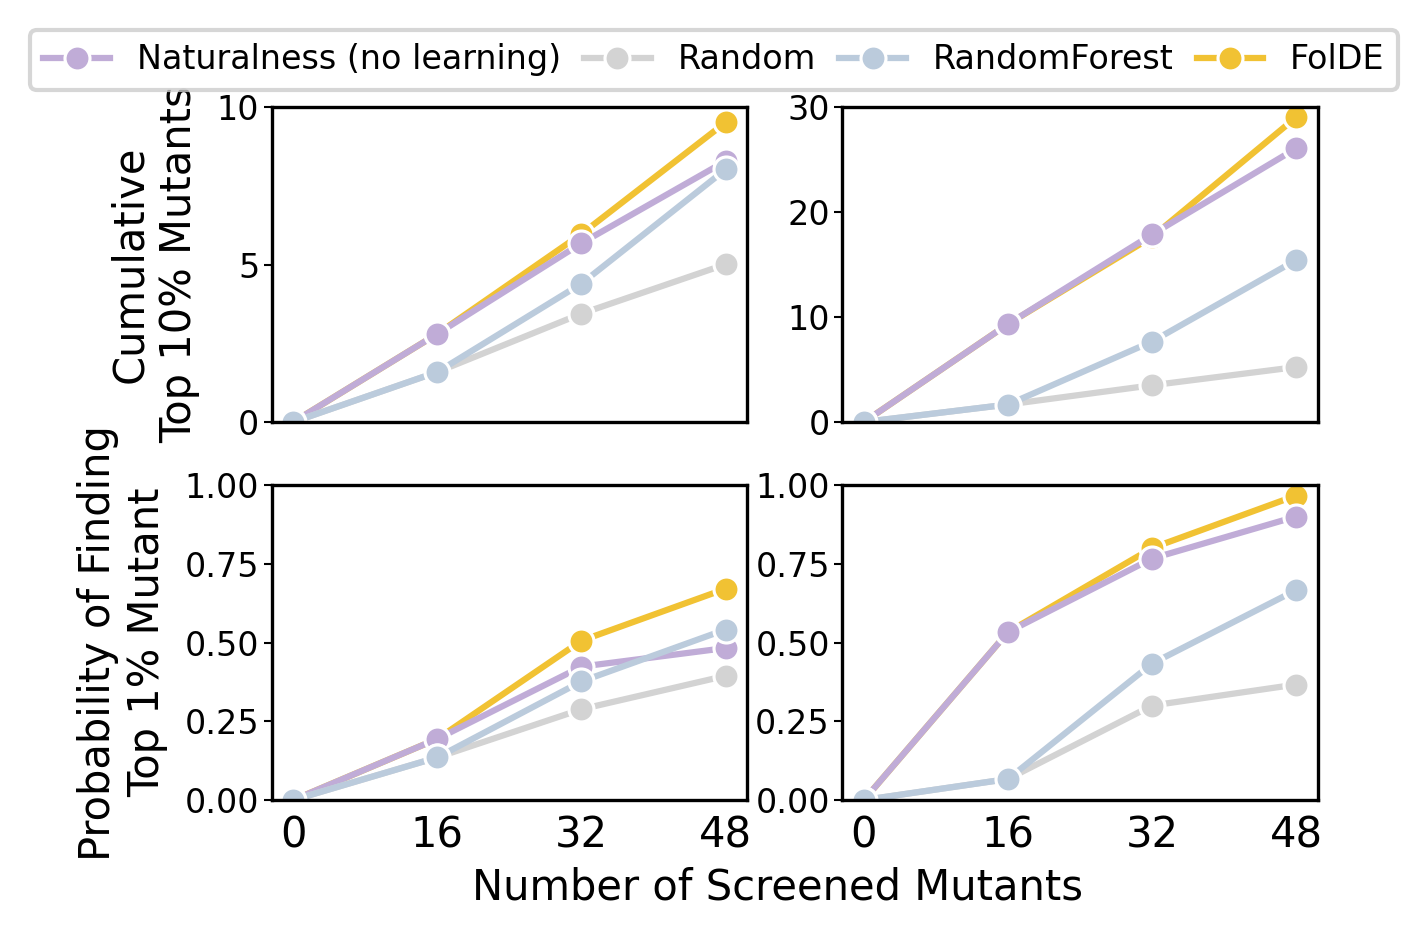

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'



def plot_four_panel_figure(
    _METRIC_TOP, _TOP_METRIC_LABEL,
    _METRIC_BOTTOM, _BOTTOM_METRIC_LABEL,
    _LAST_ROUND_NUM,
    _SINGLE_MUTANT_CONFIGS,
    _MULTI_MUTANT_CONFIGS,
    round_stats=3,
):
    # Create the 2x2 combined figure
    fig, ((ax_tl, ax_tr), (ax_bl, ax_br)) = plt.subplots(2, 2, figsize=(4.5, 3.0), dpi=300, sharex='col')
    def get_color(config_name):
        if config_name == 'FolDE':
            return '#F1C233'
        if config_name == 'FolDE schedule':
            return 'teal'
        elif config_name.startswith('RandomForest'):
            return '#bbcbdc'
        elif config_name == 'Random':
            return 'lightgrey'
        elif config_name == 'Naturalness (no learning)':
            return '#C0ACD7'  # minty green'#9AD9A8' # purpleish '#A5869E' # dusty purple C0ACD7
        elif config_name == 'FolDE no Constant-Liar' or config_name == 'FolDE no Warm Start':
            return (0.7143730886850153, 0.5497871319781735, 0.04902560412544221)
        else:
            return 'magenta'

    singles_plot_df = round_metrics_df_abstract.copy()

    singles_plot_df['Screened mutants'] = singles_plot_df.round_num * 16
    singles_plot_df['config_name'] = singles_plot_df.config_name.apply(lambda x: SINGLE_MUTANT_CONFIGS.get(x, x))
    singles_plot_df = singles_plot_df[
        (singles_plot_df.round_num <= LAST_ROUND_NUM) &
        (singles_plot_df.config_name.isin(SINGLE_MUTANT_CONFIGS.values()))
    ]
    singles_plot_df = pd.concat([singles_plot_df, pd.DataFrame([{
        'config_name': config_name,
        'Screened mutants': 0,
        'round_num': 0,
        'cumulative_10pct_hits': 0,
        'has_found_top_1pct': 0,
    } for config_name in SINGLE_MUTANT_CONFIGS.values()])]).reset_index()

    multi_plot_df = round_metrics_df_multi.copy().reset_index()
    multi_plot_df['Screened mutants'] = multi_plot_df.round_num * 16
    multi_plot_df['config_name'] = multi_plot_df.config_name.apply(lambda x: MULTI_MUTANT_CONFIGS.get(x, x))
    multi_plot_df = multi_plot_df[
        (multi_plot_df.round_num <= LAST_ROUND_NUM) &
        (multi_plot_df.config_name.isin(MULTI_MUTANT_CONFIGS.values()))
    ]
    multi_plot_df = pd.concat([multi_plot_df, pd.DataFrame([{
        'config_name': config_name,
        'Screened mutants': 0,
        'round_num': 0,
        'cumulative_10pct_hits': 0,
        'has_found_top_1pct': 0,
    } for config_name in MULTI_MUTANT_CONFIGS.values()])]).reset_index()

    SINGLE_MUTANT_PALETTE = {c: get_color(c) for c in SINGLE_MUTANT_CONFIGS.values()}


    sns.lineplot(
        ax=ax_tl,
        data=singles_plot_df,
        y=METRIC_TOP,
        x='Screened mutants',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=SINGLE_MUTANT_CONFIGS.values(),
        palette=SINGLE_MUTANT_PALETTE
    )

    sns.lineplot(
        ax=ax_bl,
        data=singles_plot_df,
        y=METRIC_BOTTOM,
        x='Screened mutants',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=SINGLE_MUTANT_CONFIGS.values(),
        palette=SINGLE_MUTANT_PALETTE
    )

    sns.lineplot(
        ax=ax_tr,
        data=multi_plot_df[multi_plot_df.config_name.isin(MULTI_MUTANT_CONFIGS.values())],
        y=METRIC_TOP,
        x='Screened mutants',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=MULTI_MUTANT_CONFIGS.values(),
        palette={c: get_color(c) for c in MULTI_MUTANT_CONFIGS.values()}
    )

    sns.lineplot(
        ax=ax_br,
        data=multi_plot_df[multi_plot_df.config_name.isin(MULTI_MUTANT_CONFIGS.values())],
        y=METRIC_BOTTOM,
        x='Screened mutants',
        hue='config_name',
        errorbar=None,
        marker='o',
        hue_order=MULTI_MUTANT_CONFIGS.values(),
        palette={c: get_color(c) for c in MULTI_MUTANT_CONFIGS.values()},
    )

    ax_tl.set_ylabel(TOP_METRIC_LABEL)
    ax_tl.set_xlabel('')

    ax_tr.set_xlabel('')
    ax_tr.set_ylabel('')
    ax_tr.get_legend().remove()

    ax_bl.set_xlabel('')
    ax_bl.set_ylabel(BOTTOM_METRIC_LABEL)
    ax_bl.get_legend().remove()

    ax_br.set_xlabel('')
    ax_br.set_ylabel('')
    ax_br.get_legend().remove()

    for ax in [ax_bl, ax_br]:
        ax.set_xticks(sorted(multi_plot_df['Screened mutants'].unique()))

    fig.supxlabel('Number of Screened Mutants', fontsize=10, y=-0.01)

    for ax in [ax_tl, ax_bl, ax_tr, ax_br]:
        ax.tick_params(axis='y', labelsize=8, pad=1, length=2, width=0.5)  # Shrink y-tick marks and labels
        ax.tick_params(axis='x', length=0)
    handles, labels = ax_tl.get_legend_handles_labels()
    order = list(range(1, len(handles))) + [0]
    ax_tl.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        loc='center',
        bbox_to_anchor=(0.93, 1.15),
        fontsize=8,
        ncol=4,
        columnspacing=0.7  # Add smaller column spacing
    )

    # Print stats.
    singles_last_round_stats = singles_plot_df[singles_plot_df.round_num == round_stats].groupby(['config_name']).agg({
        'cumulative_10pct_hits': 'mean',
        'has_found_top_1pct': 'mean',
    })
    multi_last_round_stats = multi_plot_df[multi_plot_df.round_num == round_stats].groupby(['config_name']).agg({
        'cumulative_10pct_hits': 'mean',
        'has_found_top_1pct': 'mean',
    })
    cumulative_df = pd.concat([singles_last_round_stats, multi_last_round_stats])
    cumulative_round_stats = cumulative_df.groupby(['config_name']).agg({
        'cumulative_10pct_hits': 'mean',
        'has_found_top_1pct': 'mean',
    })
    print(f'Stats for round {round_stats}:')
    print(singles_last_round_stats)
    print(multi_last_round_stats)
    print(cumulative_round_stats)

    if METRIC_TOP == 'frac_10pct_hits':
        # for ax in [ax_tl, ax_tr]:
        #     ax.set_ylim(0, 1.0)
        #     ax.set_yticks([0, 0.5, 1.0])
        ax_tl.set_ylim(0, 0.3)
        ax_tr.set_ylim(0, 1.0)
        ax_tr.set_yticks([0, 0.5, 1.0])
    elif METRIC_TOP == 'new_10pct_hits' or METRIC_TOP == 'cumulative_10pct_hits':
        for ax in [ax_tl, ax_tr]:
            ax.set_ylim(0, 15)
            ax.set_yticks([0, 10, 20, 30])
        ax_tl.set_ylim(0, 10)
        ax_tl.set_yticks([0, 5, 10])

    for ax in [ax_bl, ax_br]:
        ax.set_ylim(0, 1)
    return fig, (ax_tl, ax_tr, ax_bl, ax_br)


# METRIC_TOP, TOP_METRIC_LABEL = 'held_out_batch_10pct', 'Frac of Mutants in\nTop 10% Hits (held out)'
METRIC_TOP, TOP_METRIC_LABEL = 'cumulative_10pct_hits', 'Cumulative\nTop 10% Mutants'
# METRIC_TOP, TOP_METRIC_LABEL = 'new_10pct_hits', 'Number of\nNew Top 10% Hits'
# METRIC_TOP, TOP_METRIC_LABEL = 'frac_10pct_hits', 'Fraction in\nTop 10%'

METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'has_found_top_1pct', 'Probability of Finding\nTop 1% Mutant'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_activity_spearman', 'Spearman'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_1pct_recall', 'Top 10% Recall'

LAST_ROUND_NUM = 3

SINGLE_MUTANT_CONFIGS = {
    'FolDE-base': 'FolDE',
    # 'FolDE-no-constantliar': 'FolDE no CL',
    # 'FolDE-no-naturalnessTraining': 'FolDE no warm start',
    # 'FolDE-no-clS1': 'FolDE strong CL',
    # 'FolDE-with-esmv1-nocl': 'FolDE esm1v no CL',
    # 'FolDE-clS6-schedule': 'FolDE schedule',
    'OnlyNaturalness': 'Naturalness (no learning)',
    'Random': 'Random',  #'FolDE-random': 'Random',
    'RandomToRandomForest-base': 'RandomForest',# 'FolDE-Random-RandomForestCtrl': 'RandomForest'
    # 'FolDE-no-constantliar': 'FolDE (no constantliar)',
}
MULTI_MUTANT_CONFIGS = SINGLE_MUTANT_CONFIGS

fig, (ax_tl, ax_tr, ax_bl, ax_br) = plot_four_panel_figure(
    METRIC_TOP, TOP_METRIC_LABEL,
    METRIC_BOTTOM, BOTTOM_METRIC_LABEL,
    LAST_ROUND_NUM,
    SINGLE_MUTANT_CONFIGS,
    MULTI_MUTANT_CONFIGS,
    round_stats=1,
)

# for ax in [ax_tl, ax_bl, ax_tr, ax_br]:
#     ax.set_ylim(0, ax.get_ylim()[1])

# Adjust layout
# plt.tight_layout()
# plt.show()
plt.savefig('notebooks/jacob/paperplots/fig1_combined.svg', dpi=300, format='svg', bbox_inches='tight')

Stats for round 3:
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE                                   9.511765            0.670588
FolDE no Warm Start                     7.188235            0.547059
Naturalness (no learning)               8.282353            0.482353
Random                                  5.005882            0.394118
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE                                  29.033333            0.966667
FolDE no Warm Start                    21.133333            0.833333
Naturalness (no learning)              26.066667            0.900000
Random                                  5.233333            0.366667
                           cumulative_10pct_hits  has_found_top_1pct
config_name                                                         
FolDE          

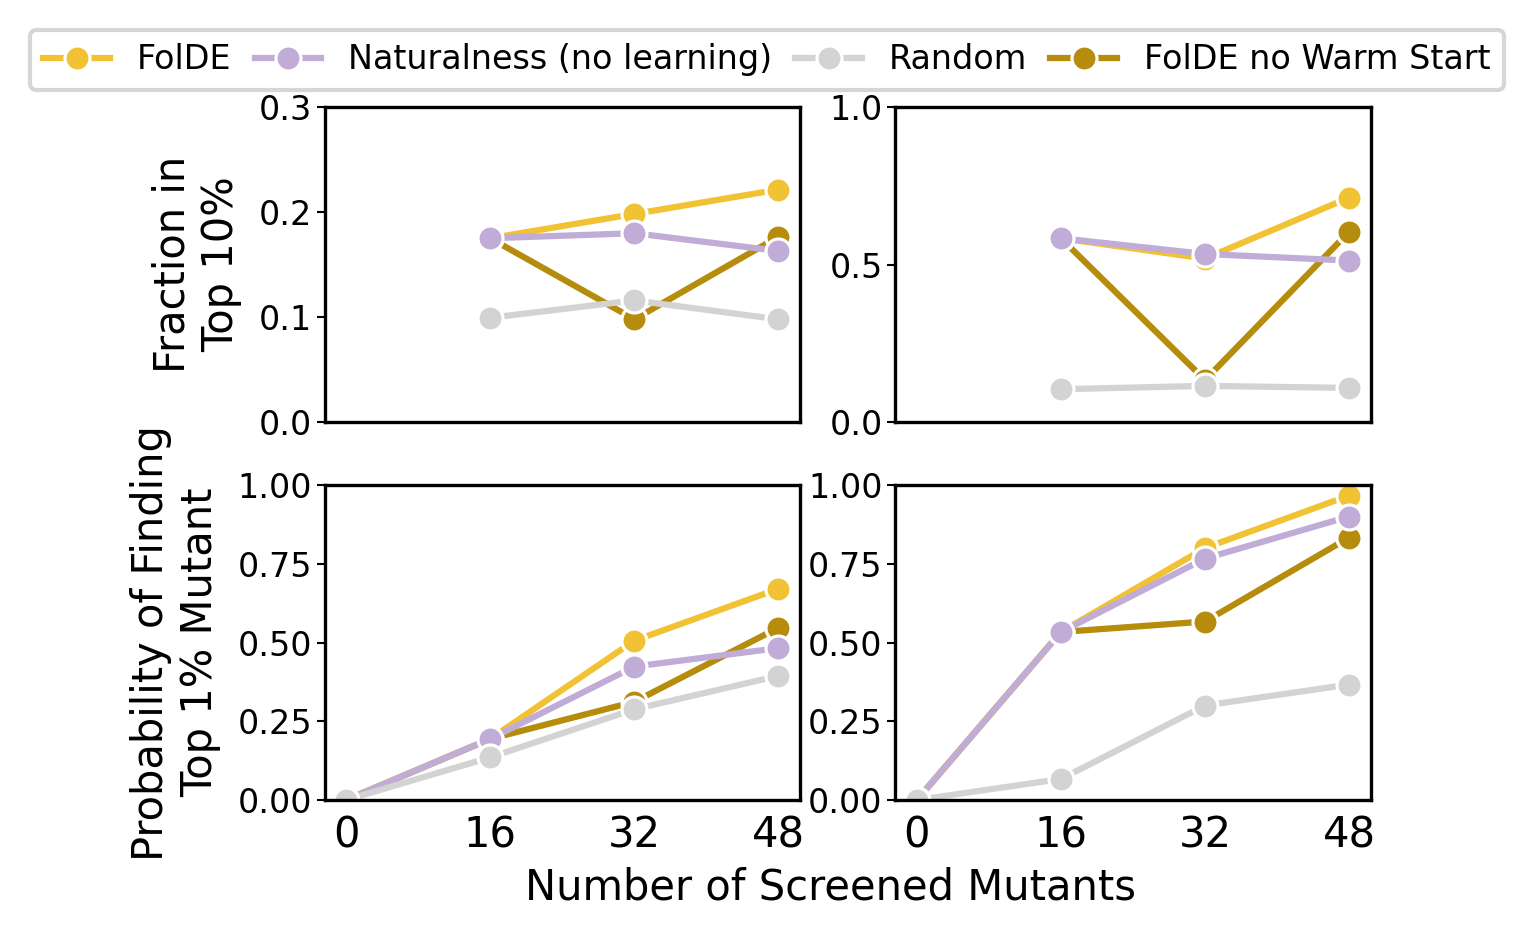

In [14]:

# # METRIC_TOP, TOP_METRIC_LABEL = 'held_out_batch_10pct', 'Frac of Mutants in\nTop 10% Hits (held out)'
# METRIC_TOP, TOP_METRIC_LABEL = 'cumulative_10pct_hits', 'Cumulative\nTop 10% Mutants'
# # METRIC_TOP, TOP_METRIC_LABEL = 'new_10pct_hits', 'Number of\nNew Top 10% Hits'

# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'has_found_top_1pct', 'Probability of Finding\nTop 1% Mutant'
# # METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_activity_spearman', 'Spearman'
# # METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_1pct_recall', 'Top 10% Recall'

LAST_ROUND_NUM = 3

SINGLE_MUTANT_CONFIGS = {
    # 'FolDE-no-zeroShot': 'FolDE -ZS +WS',
    'FolDE-no-naturalnessTraining': 'FolDE no Warm Start',
    'FolDE-base': 'FolDE',
    'OnlyNaturalness': 'Naturalness (no learning)',
    'Random': 'Random',  #'FolDE-random': 'Random',
    # 'RandomToRandomForest-base': 'RandomForest',
}
MULTI_MUTANT_CONFIGS = SINGLE_MUTANT_CONFIGS

fig, (ax_tl, ax_tr, ax_bl, ax_br) = plot_four_panel_figure(
    METRIC_TOP, TOP_METRIC_LABEL,
    METRIC_BOTTOM, BOTTOM_METRIC_LABEL,
    LAST_ROUND_NUM,
    SINGLE_MUTANT_CONFIGS,
    MULTI_MUTANT_CONFIGS
)

# for ax in [ax_tl, ax_bl, ax_tr, ax_br]:
#     ax.set_ylim(0, ax.get_ylim()[1])
# for ax in [ax_tl, ax_tr]:
#     ax.set_ylim(0, 15)
#     ax.set_yticks([0, 10, 20, 30])
# ax_tl.set_ylim(0, 10)
# ax_tl.set_yticks([0, 5, 10])

for ax in [ax_bl, ax_br]:
    ax.set_ylim(0, 1)

# Adjust layout
# plt.tight_layout()
# plt.show()
plt.savefig('notebooks/jacob/paperplots/fig2_four_panel_plot.svg', dpi=300, format='svg', bbox_inches='tight')

                        cumulative_10pct_hits  has_found_top_1pct
config_name                                                      
FolDE                                9.511765            0.670588
FolDE no Constant-Liar               9.582353            0.647059
Random                               5.005882            0.394118
RandomForest                         8.017647            0.541176
                        cumulative_10pct_hits  has_found_top_1pct
config_name                                                      
FolDE                                9.511765            0.670588
FolDE no Constant-Liar               9.582353            0.647059
Random                               5.005882            0.394118
RandomForest                         8.017647            0.541176


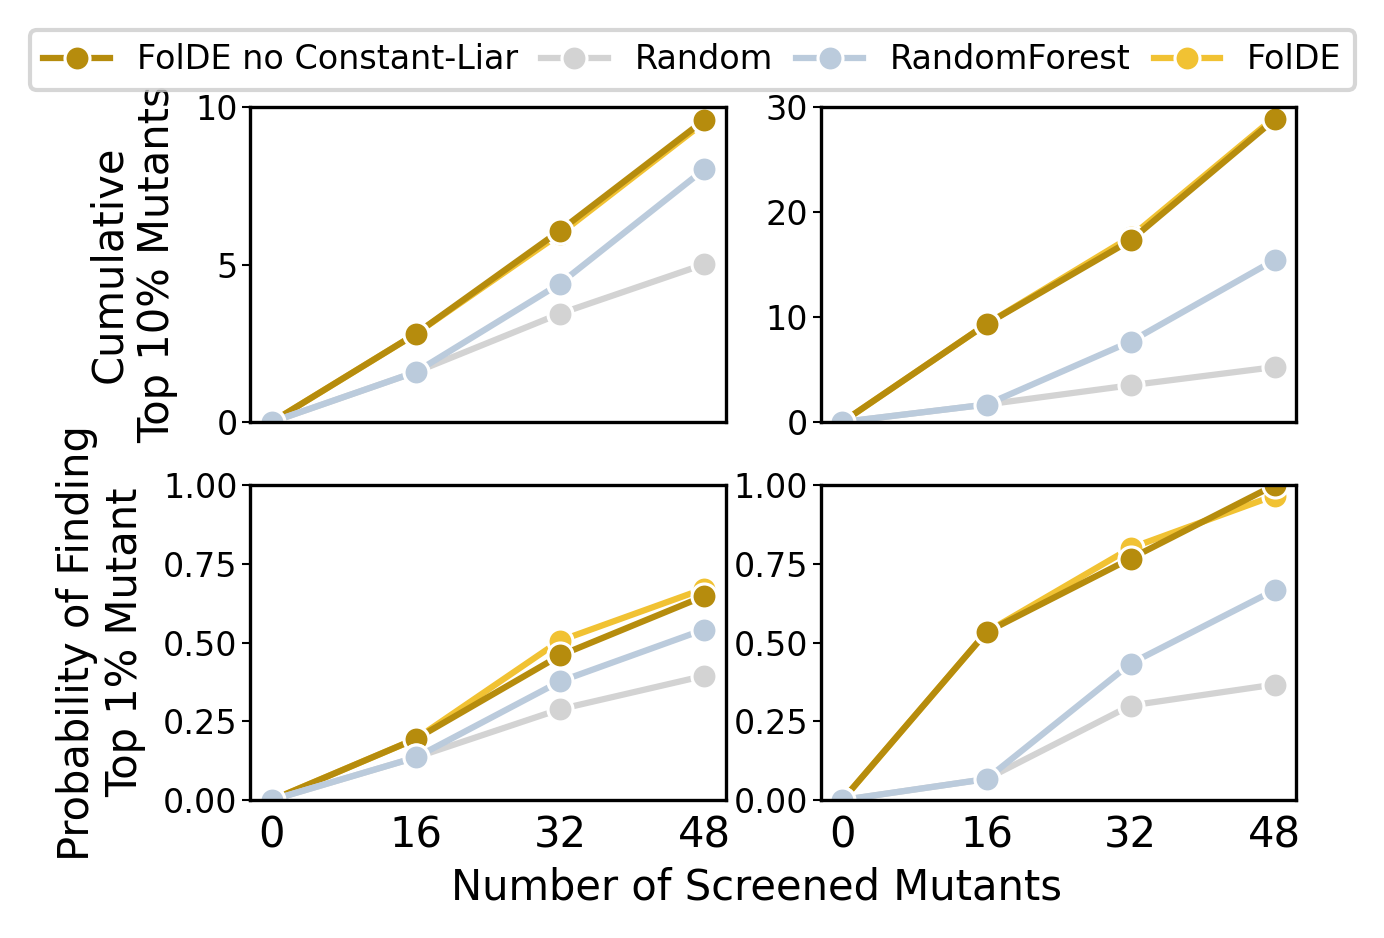

In [ ]:

# METRIC_TOP, TOP_METRIC_LABEL = 'held_out_batch_10pct', 'Frac of Mutants in\nTop 10% Hits (held out)'
METRIC_TOP, TOP_METRIC_LABEL = 'cumulative_10pct_hits', 'Cumulative\nTop 10% Mutants'
# METRIC_TOP, TOP_METRIC_LABEL = 'new_10pct_hits', 'Number of\nNew Top 10% Hits'

METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'has_found_top_1pct', 'Probability of Finding\nTop 1% Mutant'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_activity_spearman', 'Spearman'
# METRIC_BOTTOM, BOTTOM_METRIC_LABEL = 'held_out_1pct_recall', 'Top 10% Recall'

LAST_ROUND_NUM = 3

SINGLE_MUTANT_CONFIGS = {
    'FolDE-base': 'FolDE',
    'FolDE-no-constantliar': 'FolDE no Constant-Liar',
    'OnlyNaturalness': 'Zero-Shot (Naturalness Only)',
    # 'FolDE-no-naturalnessTraining': 'FolDE no warm start',
    'Random': 'Random',  #'FolDE-random': 'Random',
    'RandomToRandomForest-base': 'RandomForest',
}
MULTI_MUTANT_CONFIGS = SINGLE_MUTANT_CONFIGS

fig, (ax_tl, ax_tr, ax_bl, ax_br) = plot_four_panel_figure(
    METRIC_TOP, TOP_METRIC_LABEL,
    METRIC_BOTTOM, BOTTOM_METRIC_LABEL,
    LAST_ROUND_NUM,
    SINGLE_MUTANT_CONFIGS,
    MULTI_MUTANT_CONFIGS
)

# for ax in [ax_tl, ax_bl, ax_tr, ax_br]:
#     ax.set_ylim(0, ax.get_ylim()[1])
for ax in [ax_tl, ax_tr]:
    ax.set_ylim(0, 15)
    ax.set_yticks([0, 10, 20, 30])
ax_tl.set_ylim(0, 10)
ax_tl.set_yticks([0, 5, 10])

for ax in [ax_bl, ax_br]:
    ax.set_ylim(0, 1)

# Adjust layout
# plt.tight_layout()
# plt.show()
plt.savefig('notebooks/jacob/paperplots/fig3_four_panel_plot.svg', dpi=300, format='svg', bbox_inches='tight')